# Eds 217 Final Project: Global death trends in 2026 (January - July)
**Team members:** Sarah Busby, Gita Sharma, Elyse Owen

## About the data
The data used for analysis comes from Kaggle. The csv containes simulated data from modeled global death trends for the first half of 2026 (January through July). It is intended to practice mortality analysis without touching sensitive real data.

## Questions explored
### 1. How do death ratios compare across hemispheres over time?
### 2. How do death ratios compare across sex over continents?
### 3. What are the average age distributions across different causes of death?

## Step 1: Import the data
* Imported the necessary packages used in analysis
* Retrieved the csv data from Google Drive

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def extract_file_id(url):
    """Extract file id from Google Drive Sharing URL."""
    return url.split("/")[-2]

def df_from_gdrive_csv(url):
    """ Get the CSV file from a Google Drive Sharing URL."""
    file_id = extract_file_id(url)
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={"id": file_id}, stream=True)
    return pd.read_csv(response.raw)


sharing_url = "https://drive.google.com/file/d/1laDaQ55iP23HwzRk79WSHvruszJHWv1S/view?usp=sharing"
deaths = df_from_gdrive_csv(sharing_url)
deaths.head()

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,deaths_maternal_neonatal,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death
0,2026-01-01,Africa,1500000000,37031,11128,3770,3827,6574,2813,2087,3390,3442,2.4687,18903,18128,63.0
1,2026-01-01,Antarctica,1100,0,0,0,0,0,0,0,0,0,0.0000,0,0,44.7
2,2026-01-01,Asia,4800000000,98221,31435,17439,10838,9812,7839,5915,4852,10091,2.0463,50623,47598,71.8
3,2026-01-01,Europe,745000000,23781,8409,5286,2475,1132,1786,1387,1124,2182,3.1921,12213,11568,79.9
4,2026-01-01,North America,605000000,15733,4774,3332,1598,1467,1387,863,760,1552,2.6005,8106,7627,77.3


## Step 2: Explore
* Determined the number of rows and column types for the dataset
* Confirmed there are no null values in the data

In [2]:
deaths.shape

(1484, 16)

In [3]:
deaths.head()

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,deaths_maternal_neonatal,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death
0,2026-01-01,Africa,1500000000,37031,11128,3770,3827,6574,2813,2087,3390,3442,2.4687,18903,18128,63.0
1,2026-01-01,Antarctica,1100,0,0,0,0,0,0,0,0,0,0.0000,0,0,44.7
2,2026-01-01,Asia,4800000000,98221,31435,17439,10838,9812,7839,5915,4852,10091,2.0463,50623,47598,71.8
3,2026-01-01,Europe,745000000,23781,8409,5286,2475,1132,1786,1387,1124,2182,3.1921,12213,11568,79.9
4,2026-01-01,North America,605000000,15733,4774,3332,1598,1467,1387,863,760,1552,2.6005,8106,7627,77.3


In [4]:
deaths.isnull().sum()
# No null values

date                         0
continent                    0
population                   0
total_deaths                 0
deaths_cardiovascular        0
deaths_cancer                0
deaths_respiratory           0
deaths_infectious_disease    0
deaths_injury_accident       0
deaths_neurological          0
deaths_maternal_neonatal     0
deaths_other                 0
deaths_per_100k              0
male_deaths                  0
female_deaths                0
avg_age_at_death             0
dtype: int64

In [5]:
deaths.dtypes

date                          object
continent                     object
population                     int64
total_deaths                   int64
deaths_cardiovascular          int64
deaths_cancer                  int64
deaths_respiratory             int64
deaths_infectious_disease      int64
deaths_injury_accident         int64
deaths_neurological            int64
deaths_maternal_neonatal       int64
deaths_other                   int64
deaths_per_100k              float64
male_deaths                    int64
female_deaths                  int64
avg_age_at_death             float64
dtype: object

## Step 3: Clean
* Transformed the date column from a string to a datetime

In [6]:
# Turn 'date' column into datetime from string
deaths['date'] = pd.to_datetime(deaths['date'], format = '%Y-%m-%d')
deaths.head()

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,deaths_maternal_neonatal,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death
0,2026-01-01,Africa,1500000000,37031,11128,3770,3827,6574,2813,2087,3390,3442,2.4687,18903,18128,63.0
1,2026-01-01,Antarctica,1100,0,0,0,0,0,0,0,0,0,0.0000,0,0,44.7
2,2026-01-01,Asia,4800000000,98221,31435,17439,10838,9812,7839,5915,4852,10091,2.0463,50623,47598,71.8
3,2026-01-01,Europe,745000000,23781,8409,5286,2475,1132,1786,1387,1124,2182,3.1921,12213,11568,79.9
4,2026-01-01,North America,605000000,15733,4774,3332,1598,1467,1387,863,760,1552,2.6005,8106,7627,77.3


## Step 4: Filter
* With such a small population, Antarctica did not have enough data to conduct meaningful analysis when comparing to other continents. Therefore, we created a new dataframe without Antarctica to conduct continental comparisons

In [7]:
# Removing Antarctica - too little data
continental_deaths = deaths[~(deaths['continent'] == 'Antarctica')].copy()
continental_deaths.head(7)

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,deaths_maternal_neonatal,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death
0,2026-01-01,Africa,1500000000,37031,11128,3770,3827,6574,2813,2087,3390,3442,2.4687,18903,18128,63.0
2,2026-01-01,Asia,4800000000,98221,31435,17439,10838,9812,7839,5915,4852,10091,2.0463,50623,47598,71.8
3,2026-01-01,Europe,745000000,23781,8409,5286,2475,1132,1786,1387,1124,2182,3.1921,12213,11568,79.9
4,2026-01-01,North America,605000000,15733,4774,3332,1598,1467,1387,863,760,1552,2.6005,8106,7627,77.3
5,2026-01-01,Oceania,45000000,820,269,158,71,76,58,61,40,87,1.8222,448,372,76.6
6,2026-01-01,South America,440000000,7004,2212,1251,778,716,572,432,338,705,1.5918,3589,3415,73.2
7,2026-01-02,Africa,1500000000,35599,10655,3685,3607,6293,2647,1989,3424,3299,2.3733,18330,17269,63.6


## Step 5: Sort
* Our analysis did not require us to further sort the base dataframe

## Step 6: Transform
* We added a 'month' and 'dayofyear' column, exctracted from the datetime, for comparisons across time
* We also added columns for male and female deaths per 100k population to compare across sexes

In [8]:
# Add 'month' and 'dayofyear' for analysis
continental_deaths['month'] = continental_deaths['date'].dt.month
continental_deaths['dayofyear'] = continental_deaths['date'].dt.dayofyear
continental_deaths.tail()

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,deaths_maternal_neonatal,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death,month,dayofyear
1479,2026-07-31,Asia,4800000000,82111,26224,14577,9184,8255,6595,4997,4126,8153,1.7106,42077,40034,71.9,7,212
1480,2026-07-31,Europe,745000000,21055,7353,4616,2127,1040,1602,1208,983,2126,2.8262,10794,10261,78.6,7,212
1481,2026-07-31,North America,605000000,13633,4155,2867,1424,1282,1207,765,670,1263,2.2534,7015,6618,78.2,7,212
1482,2026-07-31,Oceania,45000000,959,313,172,117,102,77,49,47,82,2.1311,502,457,76.9,7,212
1483,2026-07-31,South America,440000000,8515,2717,1520,991,800,624,546,452,865,1.9352,4391,4124,74.3,7,212


In [9]:
continental_deaths['male_per_100k'] = continental_deaths['male_deaths'] / continental_deaths['population'] * 100000
continental_deaths['female_per_100k'] = continental_deaths['female_deaths'] / continental_deaths['population'] * 100000
continental_deaths.head()

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,deaths_maternal_neonatal,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death,month,dayofyear,male_per_100k,female_per_100k
0,2026-01-01,Africa,1500000000,37031,11128,3770,3827,6574,2813,2087,3390,3442,2.4687,18903,18128,63.0,1,1,1.260200,1.208533
2,2026-01-01,Asia,4800000000,98221,31435,17439,10838,9812,7839,5915,4852,10091,2.0463,50623,47598,71.8,1,1,1.054646,0.991625
3,2026-01-01,Europe,745000000,23781,8409,5286,2475,1132,1786,1387,1124,2182,3.1921,12213,11568,79.9,1,1,1.639329,1.552752
4,2026-01-01,North America,605000000,15733,4774,3332,1598,1467,1387,863,760,1552,2.6005,8106,7627,77.3,1,1,1.339835,1.260661
5,2026-01-01,Oceania,45000000,820,269,158,71,76,58,61,40,87,1.8222,448,372,76.6,1,1,0.995556,0.826667


## Step 7 & 8: Group and Aggregate
* Split continents by main hemisphere
* Grouped differences in sex by continent, added difference column

In [10]:
# separating northern hemisphere vs. southern hemisphere continents
northern_hemisphere = continental_deaths[
    (continental_deaths['continent'] == 'Europe') | (
        continental_deaths['continent'] == 'North America') | (
            continental_deaths['continent'] == 'Asia')
].copy()
northern_hemisphere['hemisphere'] = 'Northern Hemisphere'
print(northern_hemisphere['continent'].value_counts())

southern_hemisphere = continental_deaths[
    (continental_deaths['continent'] == 'Africa') | (
        continental_deaths['continent'] == 'South America') | (
            continental_deaths['continent'] == 'Oceania')
].copy()
southern_hemisphere['hemisphere'] = 'Southern Hemisphere'
print(southern_hemisphere['continent'].value_counts()
)

continent
Asia             212
Europe           212
North America    212
Name: count, dtype: int64
continent
Africa           212
Oceania          212
South America    212
Name: count, dtype: int64


In [11]:
# Comparing across sexes
by_sex = continental_deaths.groupby('continent').agg({'male_per_100k' : 'mean', 'female_per_100k':'mean' })
# Adding a column to compare the difference
by_sex['diff'] = by_sex['male_per_100k'] - by_sex['female_per_100k']
by_sex

,male_per_100k,female_per_100k,diff
continent,,,
Africa,1.209472,1.138537,0.070935
Asia,0.953926,0.898677,0.055249
Europe,1.574486,1.480730,0.093756
North America,1.263254,1.189813,0.073441
Oceania,0.982327,0.920335,0.061992
South America,0.898778,0.845868,0.052910


## Step 9: Join & Reshape
* Combined hemisphere dataframes for plotting

In [12]:
hemispheres = pd.concat([northern_hemisphere, southern_hemisphere])
hemispheres.tail()

,date,continent,population,total_deaths,deaths_cardiovascular,deaths_cancer,deaths_respiratory,deaths_infectious_disease,deaths_injury_accident,deaths_neurological,...,deaths_other,deaths_per_100k,male_deaths,female_deaths,avg_age_at_death,month,dayofyear,male_per_100k,female_per_100k,hemisphere
1475,2026-07-30,Oceania,45000000,909,286,143,97,108,85,56,...,92,2.0200,486,423,76.9,7,211,1.080000,0.940000,Southern Hemisphere
1476,2026-07-30,South America,440000000,8347,2742,1499,938,777,655,496,...,808,1.8970,4355,3992,73.6,7,211,0.989773,0.907273,Southern Hemisphere
1477,2026-07-31,Africa,1500000000,35964,10836,3629,3713,6218,2771,2045,...,3389,2.3976,18550,17414,64.2,7,212,1.236667,1.160933,Southern Hemisphere
1482,2026-07-31,Oceania,45000000,959,313,172,117,102,77,49,...,82,2.1311,502,457,76.9,7,212,1.115556,1.015556,Southern Hemisphere
1483,2026-07-31,South America,440000000,8515,2717,1520,991,800,624,546,...,865,1.9352,4391,4124,74.3,7,212,0.997955,0.937273,Southern Hemisphere


## Step 10: Visualization

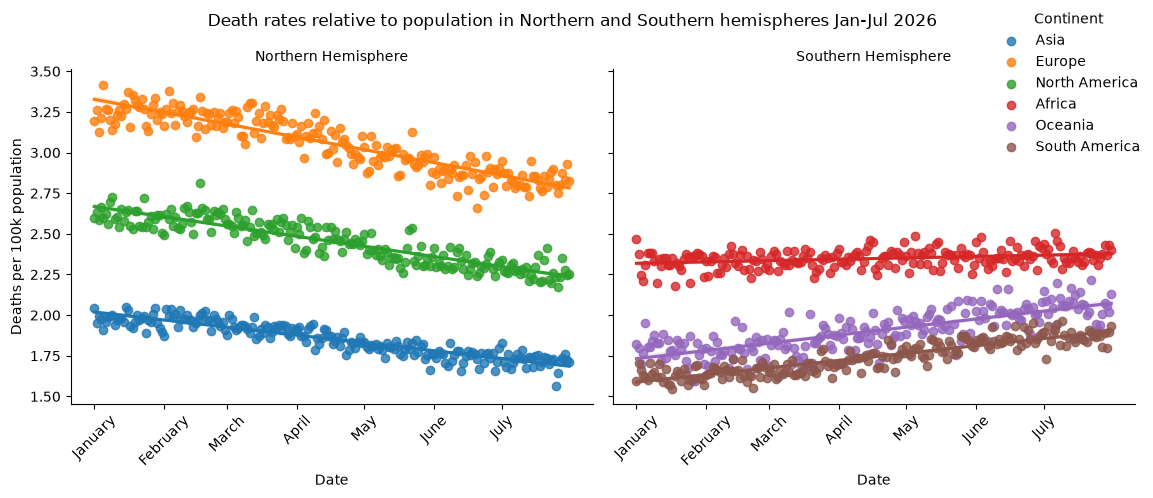

In [13]:
# Graphing death ratio overtime across continents
g = sns.lmplot(
    data=hemispheres,
    x='dayofyear',
    y='deaths_per_100k',
    hue='continent',
    col='hemisphere'
)

g.set_titles('{col_name}')
g.figure.suptitle('Death rates relative to population in Northern and Southern hemispheres Jan-Jul 2026')
g.legend.set_title('Continent')
sns.move_legend(g, "upper right")
g.set_xlabels('Date')
g.set_ylabels('Deaths per 100k population')
for ax in g.axes.flat:
    ax.set_xticks([1, 32, 60, 91, 121, 152, 182], labels=['January', 'February', 'March', 'April', 'May', 'June', 'July'], )
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


## Results for Q1: How do death ratios compare across hemispheres over time?

##### Based on our analysis, the figure shows northern hemisphere continents decreasing in deaths per 100k population from January to July while southern hemisphere continents are increasing. This could suggest seasonal differences in death ratios, as death ratios appear to be higher during winter months and lower in summer months. Further analysis across weather data for the continents would be required.

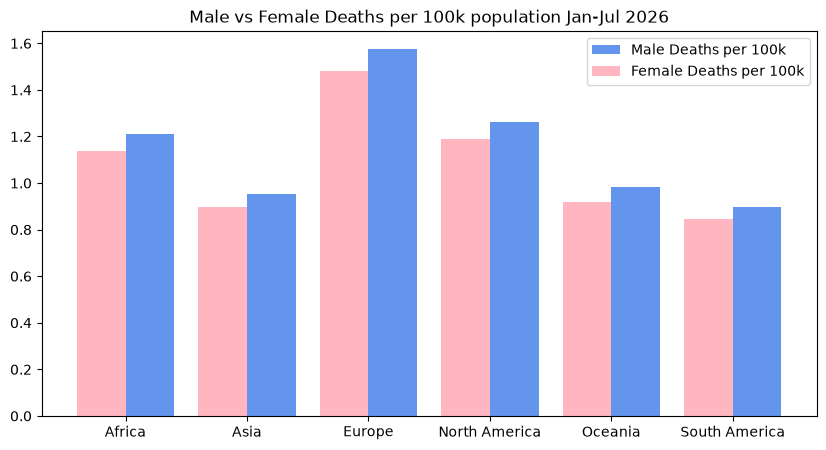

In [14]:
# Plotting Male vs Female Death ratios by continent
plt.figure(figsize=(10, 5))
plt.bar(by_sex.index, by_sex['male_per_100k'], color = 'cornflowerblue', align = 'edge', width = 0.4, label = 'Male Deaths per 100k')
plt.bar(by_sex.index, by_sex['female_per_100k'], color = 'lightpink', align = 'edge', width = -0.4, label = 'Female Deaths per 100k')
plt.legend()
plt.title('Male vs Female Deaths per 100k population Jan-Jul 2026')
plt.show()

## Results for Q2: How do death ratios compare across sex over continents?
##### This analysis shows the average number of female deaths per 100k population vs the average number of male deaths per 100k population for every continent. We can see that for every continent, the average number of male deaths exceeds the average number of female deaths.

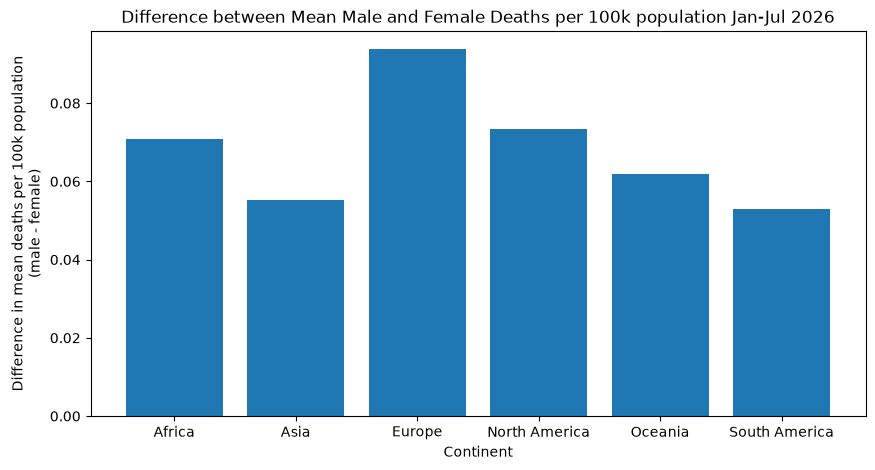

In [15]:
# Plotting the difference in mean death ratios for male vs female deaths
plt.figure(figsize=(10, 5))
plt.bar(by_sex.index, by_sex['diff'])
plt.xlabel('Continent')
plt.ylabel('Difference in mean deaths per 100k population\n(male - female)')
plt.title('Difference between Mean Male and Female Deaths per 100k population Jan-Jul 2026')
plt.show()

## Results for Q2 Continued
##### This analysis shows the difference ratio between average number of male deaths and average number of female deaths. Given that every continent shows a higher death rate for men, the height of the bar represents the amount that male deaths are higher than female deaths in each continent. We can see that Europe has the biggest discrepancy between male and female deaths while Asia has the smallest.

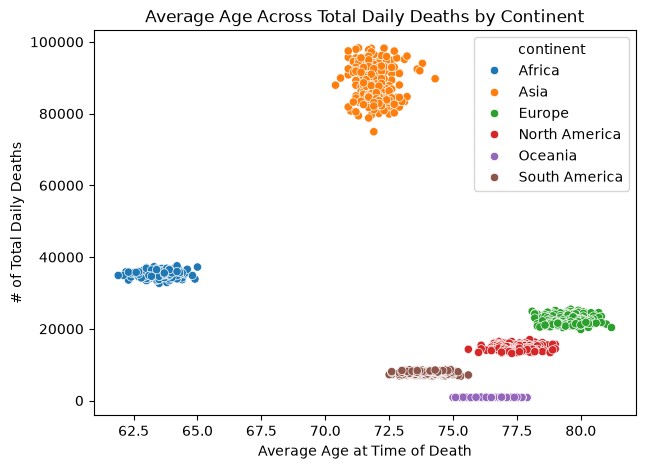

In [16]:
# Plotting average age of death compared to total daily deaths by continent
plt.figure(figsize=(7, 5))

sns.scatterplot(data=continental_deaths, x='avg_age_at_death', y='total_deaths', hue='continent')
plt.xlabel('Average Age at Time of Death')
plt.ylabel('# of Total Daily Deaths')
plt.title('Average Age Across Total Daily Deaths by Continent')
plt.show()

## Results for Q3: What are the average age distributions across different causes of death?
##### This shows the average age of individuals at time of death by continent. The total deaths y-axis reflects daily death totals, color-coded by continent. Only total deaths was plotted against average age, as the average age at time of death was calculated only for deaths per day, not against any specified cause of death.

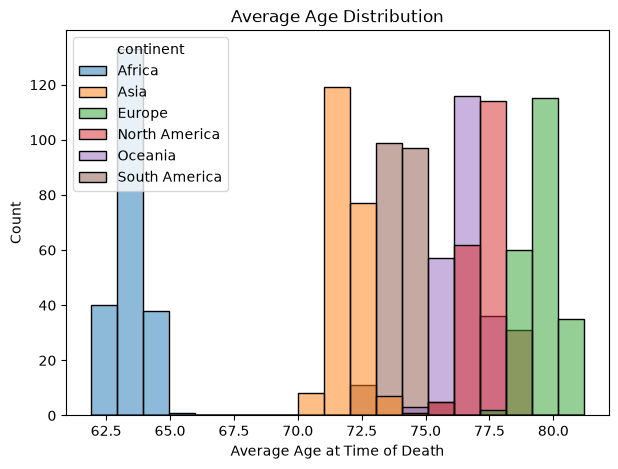

In [17]:
# Comparing the average age distribution at death by continent
plt.figure(figsize=(7, 5))

sns.histplot(data=continental_deaths, x='avg_age_at_death', hue='continent')

plt.xlabel('Average Age at Time of Death')
plt.title('Average Age Distribution')
plt.show()

## Results for Q3 Continued
##### The histogram shows the average age at time of death, grouped by continent. The original dataset had average ages already captured, and thus misleading information, such as the lack of deaths between age 65 and 70, has occurred. Antarctica was also excluded from this histogram due to inconsistencies in that data.